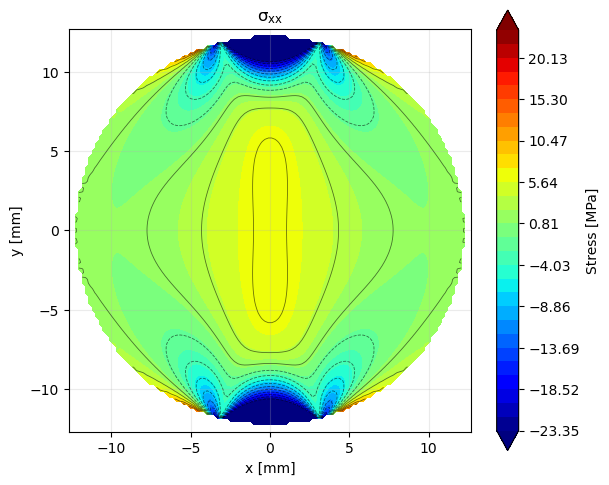

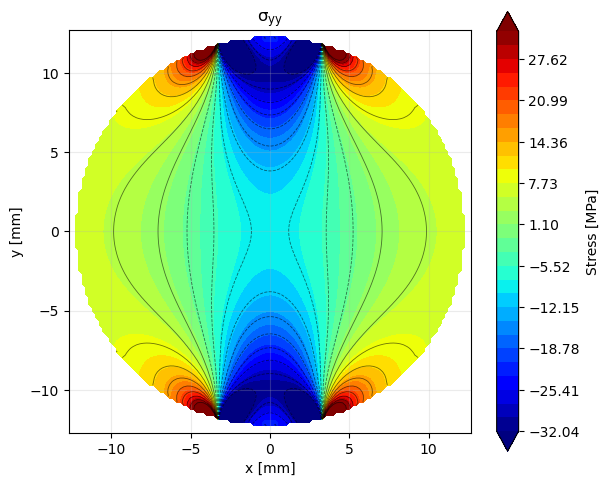

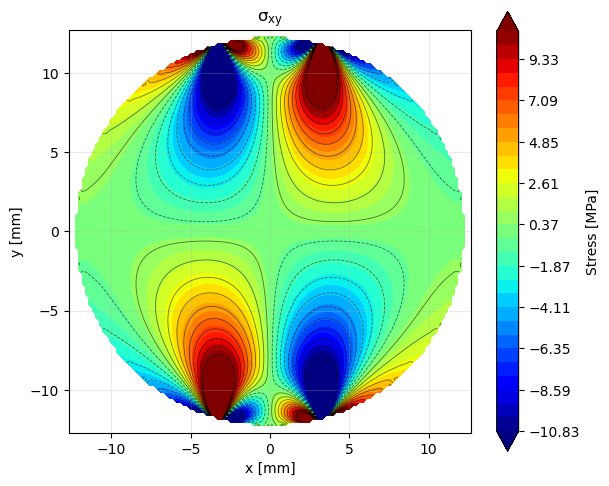

[done] mode=imposed_uy
[saved] contours + arrays in: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\BEM_Brazilian_disk_BC_selector


In [4]:
from pathlib import Path
import os, sys
import numpy as np

# -----------------------
# Repo import path
# -----------------------
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fracture_utils.Ubem.brazilian_disk_bem import BrazilianDiskParams
from fracture_utils.Ubem.boundary_conditions import build_boundary, add_boundary_to_solver
from fracture_utils.Ubem.bem_solver import BEMSolver2D
from fracture_utils.Ubem.bem_stress_field import circle_inside
from fracture_utils.Ubem.bem_stress_plotter import (
    ContourOpts,
    eval_and_plot_stress_components_contours_separate,
)
from fracture_utils.Ubem.direct_kkt_coupling import build_bem_dense_operators


# -----------------------
# User config
# -----------------------
# Choose one:
#   "traction"   -> external pressure tractions on top/bottom arcs
#   "imposed_uy" -> impose u_y on top/bottom arcs, keep u_x free (traction-free in x)
BC_MODE = "imposed_uy"

# Used only when BC_MODE == "imposed_uy" (meters)
# Top arc displacement (compressive: negative)
U_Y_TOP_IMPOSED = -4.0e-6
# Bottom arc displacement to suppress rigid-body vertical translation
U_Y_BOTTOM_IMPOSED = 0.0

# Same disk geometry/material set used in previous simulations
disk = BrazilianDiskParams(
    R=25.4e-3 / 2,
    P_total=3.8e3,
    E=231.52e9,
    nu=0.3,
    n_elem=120,
    gauss_n=6,
    plane_strain=True,
    arc_half_angle_deg=15.0,
    h=6.35e-3,
    n_grid=120,
    pad_frac=0.03,
)

out_dir = repo_root / "output" / "BEM_Brazilian_disk_BC_selector"
out_dir.mkdir(parents=True, exist_ok=True)


# -----------------------
# Utilities
# -----------------------
def _build_disk_mesh(params: BrazilianDiskParams):
    return build_boundary({"type": "circle", "R": float(params.R), "n_boundary": int(params.n_elem), "center": (0.0, 0.0)})


def _arc_masks(mesh, params: BrazilianDiskParams):
    theta_deg = np.asarray(mesh.theta_deg, dtype=float)
    arc_half = float(params.arc_half_angle_deg)
    top = (theta_deg >= 90.0 - arc_half) & (theta_deg <= 90.0 + arc_half)
    bot = (theta_deg >= -90.0 - arc_half) & (theta_deg <= -90.0 + arc_half)
    return top, bot


def _disk_external_boundary_tractions(mesh, params: BrazilianDiskParams):
    theta_deg = np.asarray(mesh.theta_deg, dtype=float)
    L = np.asarray(mesh.length, dtype=float)

    arc_half = float(params.arc_half_angle_deg)
    top = (theta_deg >= 90 - arc_half) & (theta_deg <= 90 + arc_half)
    bot = (theta_deg >= -90 - arc_half) & (theta_deg <= -90 + arc_half)

    L_top = float(np.sum(L[top]))
    L_bot = float(np.sum(L[bot]))
    if L_top <= 0 or L_bot <= 0:
        raise RuntimeError("Top/bottom loaded arc has zero length.")

    h = float(params.h)
    pressure_top = float(params.P_total) / (L_top * h)
    pressure_bot = float(params.P_total) / (L_bot * h)

    tx = np.zeros(mesh.n_seg, float)
    ty = np.zeros(mesh.n_seg, float)

    # pressure_normal => traction = -p * n_out
    tx[top] += -pressure_top * np.asarray(mesh.nx, float)[top]
    ty[top] += -pressure_top * np.asarray(mesh.ny, float)[top]

    tx[bot] += -pressure_bot * np.asarray(mesh.nx, float)[bot]
    ty[bot] += -pressure_bot * np.asarray(mesh.ny, float)[bot]

    return tx, ty, top, bot


def _solve_with_tractions(params: BrazilianDiskParams):
    mesh = _build_disk_mesh(params)
    tx, ty, _, _ = _disk_external_boundary_tractions(mesh, params)

    solver = BEMSolver2D(E=float(params.E), nu=float(params.nu), h=float(params.h), plane_strain=bool(params.plane_strain))
    is_traction = np.ones(mesh.n_seg, dtype=bool)
    add_boundary_to_solver(solver, mesh, is_traction, tx, ty)
    solver.solve(gauss_n=int(params.gauss_n))
    return solver, mesh


def _solve_with_imposed_uy(params: BrazilianDiskParams, uy_top: float, uy_bottom: float = 0.0):
    mesh = _build_disk_mesh(params)
    top, bot = _arc_masks(mesh, params)
    n = int(mesh.n_seg)

    # Build geometric segments for dense operators
    solver = BEMSolver2D(E=float(params.E), nu=float(params.nu), h=float(params.h), plane_strain=bool(params.plane_strain))
    for i in range(n):
        solver.add_element(
            float(mesh.x1[i]), float(mesh.y1[i]),
            float(mesh.x2[i]), float(mesh.y2[i]),
            True, 0.0, 0.0,
        )

    CplusH, G = build_bem_dense_operators(
        segments=solver.segs,
        E=float(params.E),
        nu=float(params.nu),
        plane_strain=bool(params.plane_strain),
        gauss_n=int(params.gauss_n),
    )

    # Unknown y = [u(2n), t(2n)] with interleaved components per segment
    C_bem = np.hstack([CplusH, -G])

    # BC rows (2n):
    #  - all segments: t_x = 0  (u_x free)
    #  - top arc:      u_y = uy_top
    #  - bottom arc:   u_y = uy_bottom (default 0 to suppress rigid-body translation)
    #  - remaining arc: t_y = 0
    C_bc = np.zeros((2 * n, 4 * n), float)
    d = np.zeros((2 * n,), float)

    for i in range(n):
        r0 = 2 * i
        r1 = 2 * i + 1

        # t_x = 0
        C_bc[r0, 2 * n + 2 * i + 0] = 1.0

        if top[i]:
            C_bc[r1, 2 * i + 1] = 1.0
            d[r1] = float(uy_top)
        elif bot[i]:
            C_bc[r1, 2 * i + 1] = 1.0
            d[r1] = float(uy_bottom)
        else:
            C_bc[r1, 2 * n + 2 * i + 1] = 1.0

    A = np.vstack([C_bem, C_bc])
    b = np.concatenate([np.zeros((2 * n,), float), d])

    # Least-squares handles the remaining x-translation gauge mode robustly.
    y, *_ = np.linalg.lstsq(A, b, rcond=None)

    u = y[: 2 * n]
    t = y[2 * n :]

    solver.u_x = np.asarray(u[0::2], float).copy()
    solver.u_y = np.asarray(u[1::2], float).copy()
    solver.t_x = np.asarray(t[0::2], float).copy()
    solver.t_y = np.asarray(t[1::2], float).copy()
    solver._colloc_xy = np.column_stack([np.asarray(mesh.xm, float), np.asarray(mesh.ym, float)])

    return solver, mesh


def _plot_stress_components(solver, params: BrazilianDiskParams, out: Path, basename: str):
    bbox = (-params.R, params.R, -params.R, params.R)
    inside = circle_inside(float(params.R), center=(0.0, 0.0), pad=float(params.pad_frac) * float(params.R))

    opts_common = dict(
        dpi=300,
        show=True,
        robust=True,
        robust_pct=97.0,
        n_levels=30,
        n_line_levels=20,
        x_scale=1e3,
        y_scale=1e3,
        x_label="x [mm]",
        y_label="y [mm]",
        value_scale=1e-6,
        cbar_label="Stress [MPa]",
        cmap="jet",
    )

    opts_xx = ContourOpts(**opts_common, title=r"$\sigma_{xx}$", symmetric=True)
    opts_yy = ContourOpts(**opts_common, title=r"$\sigma_{yy}$", symmetric=True)
    opts_xy = ContourOpts(**opts_common, title=r"$\sigma_{xy}$", symmetric=True)

    xs, ys, Sxx, Syy, Sxy, _ = eval_and_plot_stress_components_contours_separate(
        solver,
        bbox=bbox,
        out_dir=out,
        basename=basename,
        n=int(params.n_grid),
        inside=inside,
        normalize_by=None,
        opts_xx=opts_xx,
        opts_yy=opts_yy,
        opts_xy=opts_xy,
    )

    np.save(out / f"{basename}_xs.npy", xs)
    np.save(out / f"{basename}_ys.npy", ys)
    np.save(out / f"{basename}_Sxx.npy", Sxx)
    np.save(out / f"{basename}_Syy.npy", Syy)
    np.save(out / f"{basename}_Sxy.npy", Sxy)

    return xs, ys, Sxx, Syy, Sxy


# -----------------------
# Run selected boundary condition mode
# -----------------------
mode = str(BC_MODE).strip().lower()
if mode == "traction":
    solver, mesh = _solve_with_tractions(disk)
    base = "disk_traction"
elif mode == "imposed_uy":
    solver, mesh = _solve_with_imposed_uy(
        disk,
        uy_top=float(U_Y_TOP_IMPOSED),
        uy_bottom=float(U_Y_BOTTOM_IMPOSED),
    )
    base = "disk_imposed_uy"
else:
    raise ValueError("BC_MODE must be 'traction' or 'imposed_uy'.")

xs, ys, Sxx, Syy, Sxy = _plot_stress_components(solver, disk, out_dir, basename=base)

print(f"[done] mode={mode}")
print(f"[saved] contours + arrays in: {out_dir}")
